# 01 — Ingestion et prétraitement de DeepLontar

Ce notebook couvre toute la partie **data** : vérification des archives, inspection des annotations YOLO, regroupement des pages apparentées, prévention des fuites, extraction des caractères et contrôle du dataset final.

## Objectifs

À la fin du notebook, nous aurons compris :

1. comment DeepLontar est organisé ;
2. comment lire une annotation YOLO ;
3. pourquoi un split aléatoire classique est incorrect ;
4. comment `prepare_deeplontar.py` produit les crops ;
5. comment vérifier les 54 classes retenues.

In [1]:
from pathlib import Path
import hashlib
import json
import random
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw

ROOT = Path('..').resolve()
IMAGES = ROOT / 'data/deeplontar/images'
LABELS = ROOT / 'data/deeplontar/labels'
PROCESSED = ROOT / 'data/processed'
print('Racine :', ROOT)
print('Images :', len(list(IMAGES.glob('*.jpg'))))
print('Annotations :', len(list(LABELS.glob('*.txt'))))

Racine : C:\Users\sail_\Documents\Codex\2026-08-08\you\balinese-script-transliteration-cnn
Images : 600
Annotations : 600


## 1. Vérification des téléchargements

Les archives officielles sont publiées sur Figshare. Leurs empreintes MD5 attendues sont utilisées pour vérifier qu’elles ne sont ni incomplètes ni corrompues.

In [2]:
downloads = {
    'DeepLontar.zip': '62c4f50bc76fc3cb646ec1d46f6626f9',
    'DeepLontar_Labels.zip': '7da231ba9736f34ef7141c57a89b1a54',
}
for filename, expected in downloads.items():
    path = ROOT / 'data/downloads' / filename
    if path.exists():
        actual = hashlib.md5(path.read_bytes()).hexdigest()
        print(filename, 'OK' if actual == expected else 'ERREUR', actual)
    else:
        print(filename, 'archive absente — utilisez les dossiers déjà extraits')

DeepLontar.zip OK 62c4f50bc76fc3cb646ec1d46f6626f9
DeepLontar_Labels.zip OK 7da231ba9736f34ef7141c57a89b1a54


## 2. Comprendre une annotation YOLO

Chaque ligne contient `class_id x_center y_center width height`. Les quatre coordonnées sont normalisées entre 0 et 1. Elles doivent être multipliées par la largeur et la hauteur de l’image pour obtenir une boîte en pixels.

In [3]:
sample_image_path = sorted(IMAGES.glob('*.jpg'))[0]
sample_label_path = LABELS / f'{sample_image_path.stem}.txt'
lines = sample_label_path.read_text().splitlines()
print('Image :', sample_image_path.name)
print('Nombre de caractères annotés :', len(lines))
print('Premières annotations :')
print('\n'.join(lines[:5]))

Image : 100a.jpg
Nombre de caractères annotés : 222
Premières annotations :
1 0.029667 0.145000 0.039333 0.110000
8 0.057667 0.156667 0.028667 0.100000
37 0.061667 0.216667 0.023333 0.133333
37 0.173667 0.216667 0.023333 0.133333
37 0.327000 0.210000 0.023333 0.133333


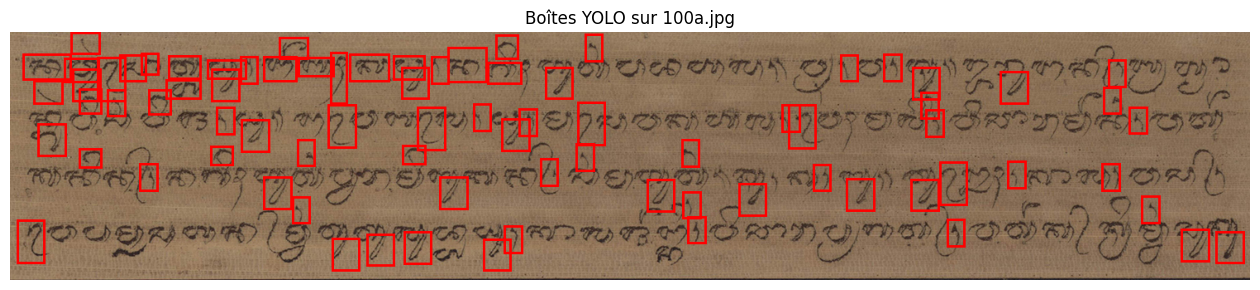

In [4]:
image = Image.open(sample_image_path).convert('RGB')
drawn = image.copy()
draw = ImageDraw.Draw(drawn)
W, H = image.size
for line in lines[:80]:
    class_id, x, y, w, h = map(float, line.split())
    left, top = (x-w/2)*W, (y-h/2)*H
    right, bottom = (x+w/2)*W, (y+h/2)*H
    draw.rectangle((left, top, right, bottom), outline='red', width=3)
plt.figure(figsize=(16, 5))
plt.imshow(drawn)
plt.title(f'Boîtes YOLO sur {sample_image_path.name}')
plt.axis('off')
plt.show()

## 3. Identifier les pages originales et augmentées

DeepLontar contient 200 pages originales et deux variantes de chaque page. Les fichiers partageant exactement le même fichier d’annotations représentent la même source. Ils doivent rester dans le même groupe afin d’éviter une fuite entre entraînement et test.

In [5]:
groups = defaultdict(list)
for label_path in LABELS.glob('*.txt'):
    digest = hashlib.sha256(label_path.read_bytes()).hexdigest()
    groups[digest].append(label_path.stem)
sizes = Counter(map(len, groups.values()))
print('Nombre de groupes sources :', len(groups))
print('Nombre de fichiers par groupe :', dict(sizes))
print('Exemples de groupes :')
for stems in list(groups.values())[:5]:
    print(stems)

Nombre de groupes sources : 200
Nombre de fichiers par groupe : {3: 200}
Exemples de groupes :
['100a', 'agt (199)', 'aug (199)']
['100b', 'agt (200)', 'aug (200)']
['10a', 'agt (19)', 'aug (19)']
['10b', 'agt (20)', 'aug (20)']
['11a', 'agt (21)', 'aug (21)']


## 4. Produire le dataset de classification

La cellule suivante appelle le script reproductible. Il ajoute 15 % de marge autour de chaque boîte, conserve les classes suffisamment présentes, cherche un split couvrant toutes les classes et réserve les variantes augmentées au train.

La régénération remplace `data/processed`. Elle est désactivée par défaut car le dataset local est déjà prêt.

In [6]:
RUN_PREPROCESSING = False
if RUN_PREPROCESSING:
    import subprocess, sys
    subprocess.run([sys.executable, str(ROOT/'prepare_deeplontar.py')], cwd=ROOT, check=True)
else:
    print('Prétraitement non relancé : data/processed existe déjà.')

Prétraitement non relancé : data/processed existe déjà.


## 5. Rapport du dataset final

In [7]:
summary = json.loads((PROCESSED/'summary.json').read_text())
print('Groupes :', summary['groups'])
print('Échantillons :', summary['samples'])
print('Classes retenues :', len(summary['retained_classes']), summary['retained_classes'])
print('Classes exclues :', summary['excluded_classes'])
print('Annotations ignorées :', summary['skipped'])

Groupes : 200
Échantillons : {'train': 95427, 'test': 6706, 'val': 6668}
Classes retenues : 54 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54]
Classes exclues : [34]
Annotations ignorées : {'out_of_schema_class': 232}


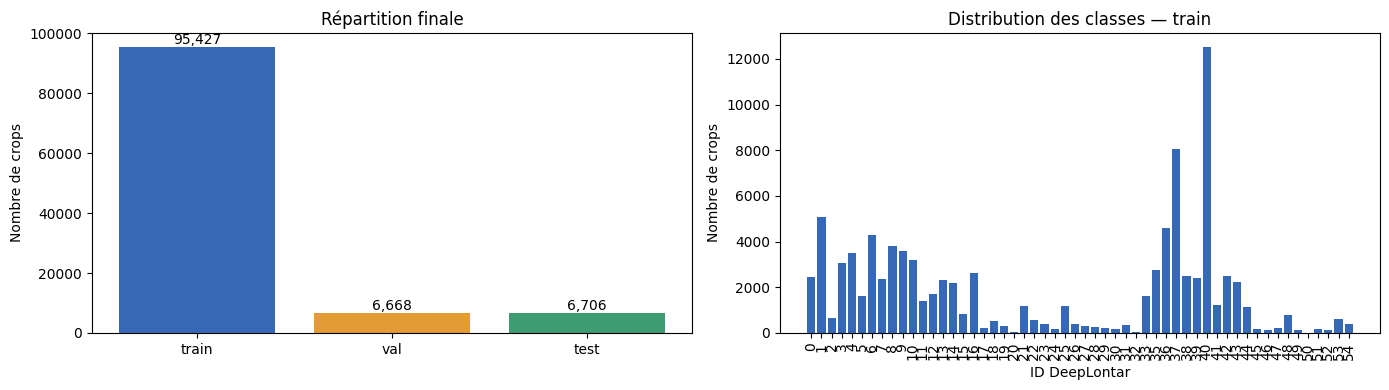

In [8]:
splits = ['train', 'val', 'test']
split_counts = [summary['samples'][name] for name in splits]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(splits, split_counts, color=['#3569b8','#e39b36','#3e9b72'])
axes[0].set(title='Répartition finale', ylabel='Nombre de crops')
for i, value in enumerate(split_counts): axes[0].text(i, value, f'{value:,}', ha='center', va='bottom')
class_counts = summary['class_counts']['train']
axes[1].bar(class_counts.keys(), class_counts.values(), color='#3569b8')
axes[1].set(title='Distribution des classes — train', xlabel='ID DeepLontar', ylabel='Nombre de crops')
axes[1].tick_params(axis='x', rotation=90)
plt.tight_layout(); plt.show()

## 6. Visualiser les crops produits

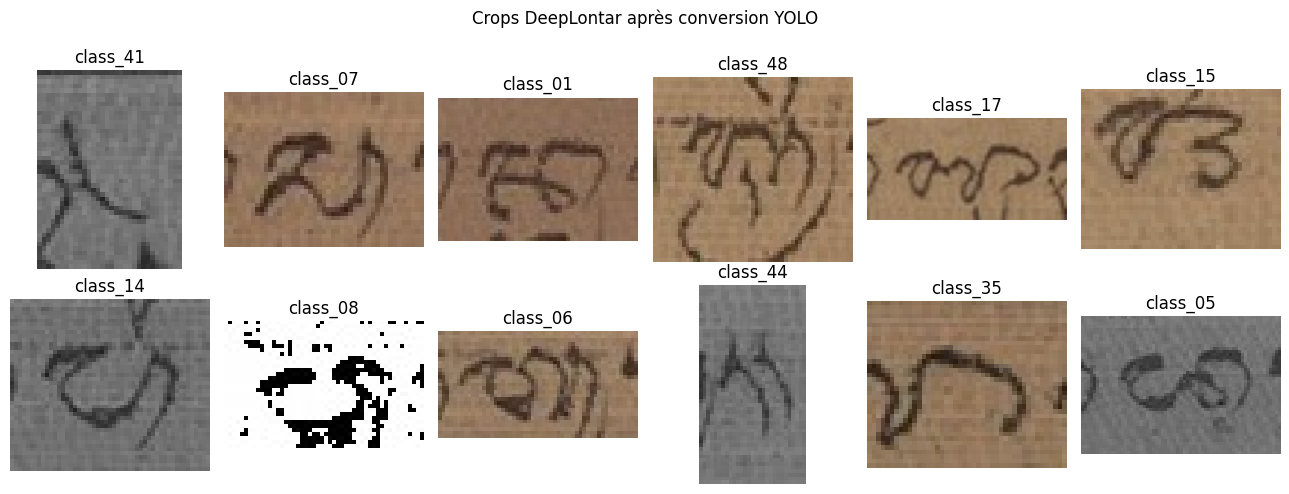

In [9]:
rng = random.Random(42)
class_dirs = sorted((PROCESSED/'train').glob('class_*'))
selected = rng.sample(class_dirs, 12)
fig, axes = plt.subplots(2, 6, figsize=(13, 5))
for axis, class_dir in zip(axes.ravel(), selected):
    path = rng.choice(list(class_dir.glob('*.jpg')))
    axis.imshow(Image.open(path))
    axis.set_title(class_dir.name)
    axis.axis('off')
plt.suptitle('Crops DeepLontar après conversion YOLO')
plt.tight_layout(); plt.show()

## Conclusion

Le pipeline de données produit 95 427 crops de train, 6 668 de validation et 6 706 de test. Les variantes d’une même page ne traversent jamais les splits. Le notebook suivant utilise ces dossiers pour entraîner ResNet18.